# Lesson 0A: Linear Regression Theory

## Introduction

Linear regression is the simplest supervised learning model with a
closed-form solution, which makes it the right place to introduce the
machinery — loss functions, gradients, the normal equation, convexity,
conditioning — that every later lesson in this corpus reuses. This notebook
works through:

1. The linear model and the squared-error loss, including why squared
   error rather than absolute error is the standard choice.
2. The normal equation, derived by setting the loss's gradient to zero,
   and what it requires of the design matrix.
3. Gradient descent as an iterative alternative, with a convergence
   argument grounded in convexity.
4. Feature scaling, motivated by the condition number of the loss's
   Hessian.
5. A from-scratch NumPy implementation of both solvers, cross-checked
   against each other to a tight numerical tolerance.
6. An application to the London housing dataset — the same data Lesson
   0B regularises.
7. The bias-variance decomposition of expected squared error, a result
   later lessons refer back to.

Lesson 0B builds on this notebook directly: it takes the ordinary
least-squares solution derived here and adds ridge, lasso and
elastic-net regularisation on top of it.


## Table of Contents

- [1. Model and Loss](#1.-Model-and-Loss)
- [2. Normal Equation](#2.-Normal-Equation)
- [3. Gradient Descent](#3.-Gradient-Descent)
- [4. Feature Scaling and Conditioning](#4.-Feature-Scaling-and-Conditioning)
- [5. From-Scratch Implementation](#5.-From-Scratch-Implementation)
- [6. Convergence Check](#6.-Convergence-Check)
- [7. Applied to Real Data](#7.-Applied-to-Real-Data)
- [8. Bias-Variance Decomposition](#8.-Bias-Variance-Decomposition)
- [Conclusion](#Conclusion)
  - [Key Insights](#Key-Insights)
  - [Further Reading](#Further-Reading)


## Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)


## 1. Model and Loss

Given a design matrix $X \in \mathbb{R}^{m \times n}$ of $m$ examples and
$n$ features (a column of ones is included for the intercept) and a target
vector $y \in \mathbb{R}^m$, the linear model predicts

$\hat y = X\beta, \qquad \beta \in \mathbb{R}^n$

so that $\hat y_i = x_i^\top \beta$ for each row $x_i$ of $X$. Fitting the
model means choosing $\beta$. The standard choice of loss is the mean
squared error, scaled by $\tfrac{1}{2}$ purely so the derivative below comes
out clean:

$J(\beta) = \dfrac{1}{2m} \lVert X\beta - y \rVert_2^2 = \dfrac{1}{2m} \sum_{i=1}^m (x_i^\top \beta - y_i)^2$

**Why squared error and not absolute error?** Two independent reasons.

*Differentiability.* Squared error $e^2$ is smooth everywhere, with
derivative $\dfrac{d}{de} e^2 = 2e$; absolute error $\lvert e \rvert$ has a
kink at $e = 0$ where $\dfrac{d}{de}\lvert e \rvert$ is undefined. Every
gradient-based method in Section 3 needs that derivative to exist
everywhere the loss is evaluated, so the kink is not a cosmetic issue.

*Maximum likelihood under Gaussian noise.* Assume the data is generated by
$y_i = x_i^\top \beta + \epsilon_i$ with $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$
drawn independently. The likelihood of the observed targets given $\beta$ is

$L(\beta) = \prod_{i=1}^m \dfrac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\dfrac{(y_i - x_i^\top \beta)^2}{2\sigma^2}\right)$

Taking logs, the terms that do not depend on $\beta$ drop out of the
maximisation, leaving

$\log L(\beta) = -\dfrac{1}{2\sigma^2}\sum_{i=1}^m (y_i - x_i^\top \beta)^2 + \text{const}$

so maximising the log-likelihood is exactly minimising
$\sum_i (y_i - x_i^\top \beta)^2$ — squared-error loss is the maximum
likelihood estimator under Gaussian noise. Minimising absolute error
instead is the maximum likelihood estimator under Laplace-distributed
noise: a defensible, more outlier-robust assumption, but a different one
from the Gaussian assumption ordinary least squares makes.

In [2]:
# The kink in absolute error versus the smoothness of squared error, made concrete.
e = np.linspace(-2, 2, 9)
squared_deriv = 2 * e
abs_deriv = np.sign(e)
print("e:              ", np.round(e, 2))
print("d/de e^2:       ", np.round(squared_deriv, 2))
print("d/de |e| (sign):", abs_deriv, "<- undefined at e=0, not a smooth function")


e:               [-2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2. ]
d/de e^2:        [-4. -3. -2. -1.  0.  1.  2.  3.  4.]
d/de |e| (sign): [-1. -1. -1. -1.  0.  1.  1.  1.  1.] <- undefined at e=0, not a smooth function


## 2. Normal Equation

$J(\beta)$ is a quadratic function of $\beta$, so its minimiser can be
found in closed form by expanding it and setting the gradient to zero.
Expanding the squared norm:

$J(\beta) = \dfrac{1}{2m}(X\beta - y)^\top(X\beta - y) = \dfrac{1}{2m}\left(\beta^\top X^\top X \beta - 2y^\top X \beta + y^\top y\right)$

Differentiating with respect to the vector $\beta$ (using
$\nabla_\beta(\beta^\top A \beta) = 2A\beta$ for symmetric $A$, and
$\nabla_\beta(b^\top \beta) = b$):

$\nabla_\beta J(\beta) = \dfrac{1}{2m}\left(2X^\top X \beta - 2X^\top y\right) = \dfrac{1}{m}\left(X^\top X \beta - X^\top y\right)$

Setting $\nabla_\beta J(\beta) = 0$ gives the **normal equation**:

$X^\top X \beta = X^\top y \quad\Longrightarrow\quad \hat\beta = (X^\top X)^{-1} X^\top y$

**Invertibility.** $X^\top X$ is invertible if and only if $X$ has full
column rank $n$ — no feature (including the intercept column) is an exact
linear combination of the others. If two features are perfectly collinear,
$X^\top X$ is singular: the loss still has a minimum, but it is achieved
along an entire line or subspace of $\beta$ values rather than at a single
point, so $\hat\beta$ is not unique. In practice, near-collinearity (rather
than exact collinearity) is more common and does not make $X^\top X$
exactly singular, but makes it ill-conditioned — Section 4 makes this
precise. When $X^\top X$ is singular or near-singular, the Moore-Penrose
pseudoinverse $X^+$ gives the minimum-norm solution
$\hat\beta = X^+ y$ instead of failing outright.

In [3]:
# Collinearity makes X^T X singular: a duplicated column has no unique coefficient split.
X_ok = rng.normal(size=(50, 3))
X_collinear = np.column_stack([X_ok, X_ok[:, 0] * 2.0])  # 4th column = 2 * 1st column

rank_ok = np.linalg.matrix_rank(X_ok)
rank_collinear = np.linalg.matrix_rank(X_collinear)
cond_ok = np.linalg.cond(X_ok.T @ X_ok)
cond_collinear = np.linalg.cond(X_collinear.T @ X_collinear)

print(f"full-rank design:   rank={rank_ok} of {X_ok.shape[1]}, cond(X^T X)={cond_ok:.2e}")
print(f"collinear design:   rank={rank_collinear} of {X_collinear.shape[1]}, cond(X^T X)={cond_collinear:.2e}")
print(f"\ncollinear X^T X is singular: {np.isclose(np.linalg.det(X_collinear.T @ X_collinear), 0.0)}")


full-rank design:   rank=3 of 3, cond(X^T X)=2.41e+00
collinear design:   rank=3 of 4, cond(X^T X)=1.47e+16

collinear X^T X is singular: True


## 3. Gradient Descent

The normal equation requires inverting an $n \times n$ matrix, which costs
$O(n^3)$ and becomes expensive as the feature count grows. Gradient descent
instead minimises $J(\beta)$ iteratively, using the same gradient derived
above:

$\beta \leftarrow \beta - \alpha \nabla_\beta J(\beta) = \beta - \alpha \cdot \dfrac{1}{m}X^\top(X\beta - y)$

where $\alpha$ is the learning rate.

**Why this converges.** $J$'s Hessian — the matrix of second derivatives —
is

$\nabla^2_\beta J(\beta) = \dfrac{1}{m}X^\top X$

which is positive semi-definite for any $X$: for any vector $z$,
$z^\top X^\top X z = \lVert Xz \rVert_2^2 \ge 0$. A twice-differentiable
function with a positive semi-definite Hessian everywhere is convex, so
$J$ is convex — it has no local minima that are not also global minima,
and (given full column rank, so the Hessian is positive *definite*) that
global minimum is unique. This is exactly the normal-equation solution
from Section 2.

Convexity alone does not guarantee gradient descent converges — the step
size matters. For a quadratic with Hessian eigenvalues bounded by
$\lambda_{\max}$, the standard stability condition is

$\alpha < \dfrac{2}{\lambda_{\max}}$

where $\lambda_{\max}$ is the largest eigenvalue of $\dfrac{1}{m}X^\top X$.
Above this threshold, each step overshoots the minimum by more than it
undershot on the previous step, and the iterates diverge rather than
converge; below it, the loss decreases monotonically toward the unique
minimum.

In [4]:
# Verify the stability bound directly: below 2/lambda_max, GD converges; at/above it, it diverges.
X_toy = StandardScaler().fit_transform(rng.normal(size=(200, 4)))
X_toy = np.column_stack([np.ones(len(X_toy)), X_toy])
true_beta = np.array([1.0, 2.0, -1.5, 0.5, 3.0])
y_toy = X_toy @ true_beta + 0.05 * rng.normal(size=len(X_toy))

hessian = (X_toy.T @ X_toy) / len(X_toy)
lambda_max = np.linalg.eigvalsh(hessian).max()
stable_alpha = 1.0 / lambda_max          # comfortably inside alpha < 2 / lambda_max
unstable_alpha = 2.2 / lambda_max        # just past the bound

def run_gd(X, y, alpha, n_iters=60):
    beta = np.zeros(X.shape[1])
    losses = []
    for _ in range(n_iters):
        grad = (X.T @ (X @ beta - y)) / len(X)
        beta = beta - alpha * grad
        losses.append(np.mean((X @ beta - y) ** 2))
    return np.array(losses)

losses_stable = run_gd(X_toy, y_toy, stable_alpha)
losses_unstable = run_gd(X_toy, y_toy, unstable_alpha)

print(f"lambda_max = {lambda_max:.4f}, stability bound 2/lambda_max = {2 / lambda_max:.4f}")
print(f"alpha = {stable_alpha:.4f} (< bound): loss goes {losses_stable[0]:.4f} -> {losses_stable[-1]:.6f}")
print(f"alpha = {unstable_alpha:.4f} (> bound): loss goes {losses_unstable[0]:.4f} -> {losses_unstable[-1]:.4e}")


lambda_max = 1.2902, stability bound 2/lambda_max = 1.5501
alpha = 0.7751 (< bound): loss goes 1.2491 -> 0.002082
alpha = 1.7051 (> bound): loss goes 6.1841 -> 2.6075e+05


## 4. Feature Scaling and Conditioning

The stability bound above depends on $\lambda_{\max}$, but convergence
*speed* depends on the whole spectrum of $\dfrac{1}{m}X^\top X$ through its
**condition number**:

$\kappa\!\left(X^\top X\right) = \dfrac{\lambda_{\max}}{\lambda_{\min}}$

Geometrically, $J(\beta)$'s contours are ellipses whose axis ratio is
$\sqrt{\kappa}$. When features are on very different scales, those
ellipses become long and thin, and gradient descent — which always steps
perpendicular to the local contour — zig-zags across the short axis while
crawling along the long one, needing far more iterations for the same
improvement in loss. Standardising each feature to zero mean and unit
variance does not change the location of the minimum, but it reshapes the
loss surface toward circular contours ($\kappa$ close to $1$), because no
feature's raw scale can dominate the others any more.

kappa(X^T X), ill-conditioned design: 2.95e+05  (own safe step size 3.77e-06)
kappa(X^T X), standardised design:    1.18e+00  (own safe step size 9.17e-01)
loss after 200 steps, ill-conditioned: 3.0841 -> 3.0786 (barely moved)
loss after 200 steps, standardised:    0.0160 -> 0.002579


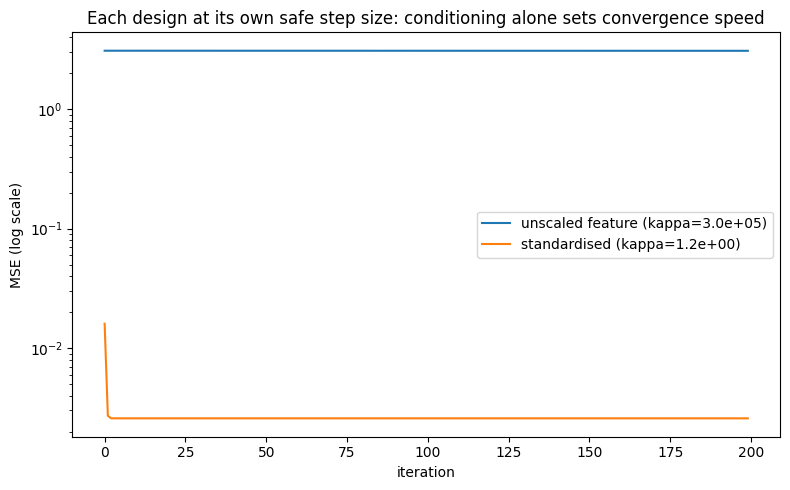

In [5]:
# Empirical demonstration: give each design its OWN stability-respecting step size
# (alpha = 1 / lambda_max, isolating the conditioning effect from the separate
# stability-bound story in Section 3) and compare how many iterations of progress
# that step size buys. A large kappa means most directions have much smaller
# curvature than the one that sets alpha, so those directions barely move.
X_base = rng.normal(size=(200, 3))
X_illconditioned = X_base.copy()
X_illconditioned[:, 0] *= 500.0  # one feature left on a wildly larger scale
X_illconditioned = np.column_stack([np.ones(len(X_illconditioned)), X_illconditioned])

X_scaled = np.column_stack([np.ones(len(X_base)), StandardScaler().fit_transform(X_base)])

beta_true = np.array([1.0, 0.01, 1.0, -1.0])  # small coef on the inflated-scale feature keeps y comparable
y_shared = X_scaled @ beta_true + 0.05 * rng.normal(size=len(X_base))

def condition_number_and_lambda_max(X):
    hessian = (X.T @ X) / len(X)
    eigvals = np.linalg.eigvalsh(hessian)
    return eigvals.max() / eigvals.min(), eigvals.max()

kappa_ill, lambda_max_ill = condition_number_and_lambda_max(X_illconditioned)
kappa_scaled, lambda_max_scaled = condition_number_and_lambda_max(X_scaled)

alpha_ill = 1.0 / lambda_max_ill
alpha_scaled = 1.0 / lambda_max_scaled

loss_ill = run_gd(X_illconditioned, y_shared, alpha_ill, n_iters=200)
loss_scaled = run_gd(X_scaled, y_shared, alpha_scaled, n_iters=200)

print(f"kappa(X^T X), ill-conditioned design: {kappa_ill:.2e}  (own safe step size {alpha_ill:.2e})")
print(f"kappa(X^T X), standardised design:    {kappa_scaled:.2e}  (own safe step size {alpha_scaled:.2e})")
print(f"loss after 200 steps, ill-conditioned: {loss_ill[0]:.4f} -> {loss_ill[-1]:.4f} (barely moved)")
print(f"loss after 200 steps, standardised:    {loss_scaled[0]:.4f} -> {loss_scaled[-1]:.6f}")

plt.figure(figsize=(8, 5))
plt.plot(loss_ill, label=f"unscaled feature (kappa={kappa_ill:.1e})")
plt.plot(loss_scaled, label=f"standardised (kappa={kappa_scaled:.1e})")
plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('MSE (log scale)')
plt.title('Each design at its own safe step size: conditioning alone sets convergence speed')
plt.legend()
plt.tight_layout()
plt.show()


## 5. From-Scratch Implementation

Two estimators, implementing the two derivations above directly: the
normal equation solved once, and gradient descent iterated to
convergence. The normal-equation solver uses `np.linalg.lstsq` on the
design matrix directly, computing the equivalent
$\hat\beta = X_{design}^+ y$ (the Moore-Penrose pseudoinverse solution
from Section 2) via SVD rather than explicitly forming and inverting
$X_{design}^\top X_{design}$. Two independent reasons favour this over
`np.linalg.solve` on the explicit normal equations: it degrades gracefully
to the minimum-norm solution when $X^\top X$ is singular or near-singular
(Section 2's collinearity case) instead of raising, and — as Lesson 0B's
own cross-check found — forming $X^\top X$ explicitly squares the design
matrix's condition number, which can cost enough precision to fail a tight
numerical comparison even when the system is technically invertible.

In [6]:
class NormalEquationRegressor:
    """Ordinary least squares via the closed-form normal equation, solved with lstsq."""

    def __init__(self):
        self.beta_ = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "NormalEquationRegressor":
        X_design = np.column_stack([np.ones(len(X)), X])
        self.beta_, *_ = np.linalg.lstsq(X_design, y, rcond=None)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_design = np.column_stack([np.ones(len(X)), X])
        return X_design @ self.beta_


class GradientDescentRegressor:
    """Ordinary least squares via batch gradient descent."""

    def __init__(self, learning_rate: float = 0.1, n_iterations: int = 2000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.beta_ = None
        self.loss_history_ = []

    def fit(self, X: np.ndarray, y: np.ndarray) -> "GradientDescentRegressor":
        X_design = np.column_stack([np.ones(len(X)), X])
        m = len(X_design)
        self.beta_ = np.zeros(X_design.shape[1])
        self.loss_history_ = []
        for _ in range(self.n_iterations):
            residual = X_design @ self.beta_ - y
            grad = (X_design.T @ residual) / m
            self.beta_ = self.beta_ - self.lr * grad
            self.loss_history_.append(float(np.mean(residual ** 2) / 2))
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        X_design = np.column_stack([np.ones(len(X)), X])
        return X_design @ self.beta_


print("NormalEquationRegressor and GradientDescentRegressor defined.")


NormalEquationRegressor and GradientDescentRegressor defined.


## 6. Convergence Check

Both estimators minimise the same convex $J(\beta)$, so with full column
rank they must converge to the same $\hat\beta$. We verify this on a
controlled synthetic problem — standardised features, so $\kappa$ is small
and gradient descent converges quickly at a step size derived directly
from $\lambda_{\max}$ — and check the two solutions agree to at least
$10^{-6}$.

normal-equation beta: [ 0.696401  2.995425 -2.000003  0.502736  1.501997 -0.998438]
gradient-descent beta: [ 0.696401  2.995425 -2.000003  0.502736  1.501997 -0.998438]
max |normal_eq_beta - gd_beta| = 6.550e-15
PASS: gradient descent converges to the normal-equation solution to within 1e-6


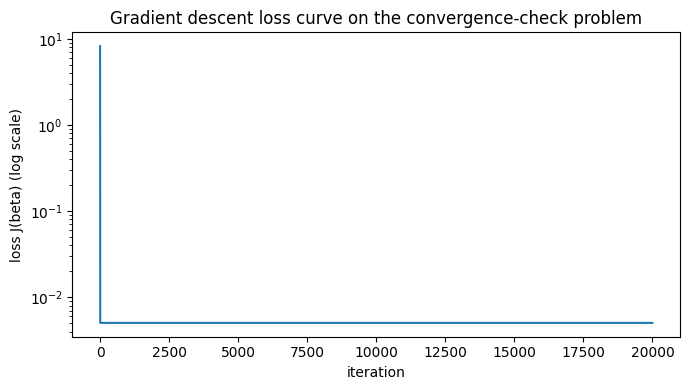

In [7]:
X_check = StandardScaler().fit_transform(rng.normal(size=(500, 5)))
true_beta_check = np.array([3.0, -2.0, 0.5, 1.5, -1.0])
y_check = 0.7 + X_check @ true_beta_check + 0.1 * rng.normal(size=len(X_check))

hessian_check = (np.column_stack([np.ones(len(X_check)), X_check])).T @ np.column_stack([np.ones(len(X_check)), X_check]) / len(X_check)
lambda_max_check = np.linalg.eigvalsh(hessian_check).max()
alpha_check = 1.0 / lambda_max_check  # inside the alpha < 2/lambda_max stability bound

normal_model = NormalEquationRegressor().fit(X_check, y_check)
gd_model = GradientDescentRegressor(learning_rate=alpha_check, n_iterations=20000).fit(X_check, y_check)

max_abs_diff = float(np.max(np.abs(normal_model.beta_ - gd_model.beta_)))
print(f"normal-equation beta: {np.round(normal_model.beta_, 6)}")
print(f"gradient-descent beta: {np.round(gd_model.beta_, 6)}")
print(f"max |normal_eq_beta - gd_beta| = {max_abs_diff:.3e}")
assert max_abs_diff < 1e-6, "gradient descent did not converge to the normal-equation solution"
print("PASS: gradient descent converges to the normal-equation solution to within 1e-6")

plt.figure(figsize=(7, 4))
plt.plot(gd_model.loss_history_)
plt.yscale('log')
plt.xlabel('iteration')
plt.ylabel('loss J(beta) (log scale)')
plt.title('Gradient descent loss curve on the convergence-check problem')
plt.tight_layout()
plt.show()


## 7. Applied to Real Data

We apply both estimators to the London housing dataset that Lesson 0B
regularises, using the same feature preparation: `House Type` one-hot
encoded, `Area in sq ft` and `No. of Bedrooms` used directly, and the
154-value `Outcode` field replaced with a smoothed target (mean-price)
encoding fit on the training split only, to avoid leaking test-set
statistics into training. Continuous features are standardised (fit on
train only) for the reasons in Section 4. This notebook fetches no
external dataset over the network — the CSV is already checked into the
repository and reusing it keeps 0A and 0B built on identical data.

In [8]:
df = pd.read_csv('../data/df_with_outcode.csv')
model_df = df[['Price', 'House Type', 'Area in sq ft', 'No. of Bedrooms', 'Outcode']].copy()
assert model_df.isna().sum().sum() == 0, "unexpected missing values in modelling columns"

X_raw = model_df.drop(columns=['Price'])
y_housing = model_df['Price'].to_numpy(dtype=float)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_housing, test_size=0.2, random_state=RANDOM_STATE
)
X_train_raw = X_train_raw.copy()
X_test_raw = X_test_raw.copy()

def fit_target_encoding(categories, target, smoothing=10.0):
    frame = pd.DataFrame({'cat': categories.to_numpy(), 'y': target})
    global_mean = frame['y'].mean()
    stats_by_cat = frame.groupby('cat')['y'].agg(['mean', 'count'])
    smoothed = (stats_by_cat['count'] * stats_by_cat['mean'] + smoothing * global_mean) / (
        stats_by_cat['count'] + smoothing
    )
    return smoothed, global_mean

encoding, global_mean = fit_target_encoding(X_train_raw['Outcode'], y_train)
X_train_raw['outcode_encoded'] = X_train_raw['Outcode'].map(encoding).fillna(global_mean).to_numpy(dtype=float)
X_test_raw['outcode_encoded'] = X_test_raw['Outcode'].map(encoding).fillna(global_mean).to_numpy(dtype=float)

house_type_train = pd.get_dummies(X_train_raw['House Type'], prefix='house', drop_first=True)
house_type_test = pd.get_dummies(X_test_raw['House Type'], prefix='house', drop_first=True)
house_type_test = house_type_test.reindex(columns=house_type_train.columns, fill_value=0)

continuous_cols = ['Area in sq ft', 'No. of Bedrooms', 'outcode_encoded']
scaler = StandardScaler().fit(X_train_raw[continuous_cols])
train_cont = pd.DataFrame(scaler.transform(X_train_raw[continuous_cols]), columns=continuous_cols, index=X_train_raw.index)
test_cont = pd.DataFrame(scaler.transform(X_test_raw[continuous_cols]), columns=continuous_cols, index=X_test_raw.index)

X_train = pd.concat([train_cont, house_type_train], axis=1).to_numpy(dtype=float)
X_test = pd.concat([test_cont, house_type_test], axis=1).to_numpy(dtype=float)

print(X_train.shape, X_test.shape)


(2784, 10) (696, 10)


In [9]:
def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return float(1 - ss_res / ss_tot)

normal_housing = NormalEquationRegressor().fit(X_train, y_train)
gd_housing = GradientDescentRegressor(learning_rate=0.3, n_iterations=5000).fit(X_train, y_train)

for name, model in [('Normal equation', normal_housing), ('Gradient descent', gd_housing)]:
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    print(f"{name}:")
    print(f"  train RMSE={rmse(y_train, y_pred_train):,.0f}  R2={r_squared(y_train, y_pred_train):.4f}")
    print(f"  test  RMSE={rmse(y_test, y_pred_test):,.0f}  R2={r_squared(y_test, y_pred_test):.4f}")


Normal equation:
  train RMSE=1,473,771  R2=0.6139
  test  RMSE=1,206,647  R2=0.5436
Gradient descent:
  train RMSE=1,473,836  R2=0.6139
  test  RMSE=1,206,773  R2=0.5435


## 8. Bias-Variance Decomposition

Fix a test point $x_0$ with true (noise-free) response $f(x_0)$, so that
observed targets are $y_0 = f(x_0) + \epsilon$ with $\mathbb{E}[\epsilon] = 0$
and $\mathrm{Var}(\epsilon) = \sigma^2$. Let $\hat f$ denote a model fit on
a training set drawn at random; the randomness of the training set makes
$\hat f(x_0)$ itself a random variable. The expected squared error at
$x_0$, averaged over both the training-set randomness and the test-point
noise, decomposes as

$\mathbb{E}\!\left[(y_0 - \hat f(x_0))^2\right] = \underbrace{\left(f(x_0) - \mathbb{E}[\hat f(x_0)]\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}\!\left[\left(\hat f(x_0) - \mathbb{E}[\hat f(x_0)]\right)^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible error}}$

**Sketch of the derivation.** Add and subtract $\mathbb{E}[\hat f(x_0)]$
inside the square:

$y_0 - \hat f(x_0) = \left(f(x_0) - \mathbb{E}[\hat f(x_0)]\right) + \left(\mathbb{E}[\hat f(x_0)] - \hat f(x_0)\right) + \epsilon$

Squaring and taking expectations, every cross term vanishes: the first
two terms are non-random with respect to $\epsilon$ so their cross term
with $\epsilon$ vanishes because $\mathbb{E}[\epsilon] = 0$, and the cross
term between the first two vanishes because
$\mathbb{E}[\mathbb{E}[\hat f(x_0)] - \hat f(x_0)] = 0$ by definition of
$\mathbb{E}[\hat f(x_0)]$. What remains is exactly the three squared terms
above.

**Where this shows up in regression.** Ordinary least squares (this
notebook) has low bias — it is an unbiased estimator of $\beta$ whenever
the linear model is correctly specified — but its variance grows with the
number of features relative to the number of training examples, and with
collinearity among features (a high condition number, Section 4,
translates directly into high variance in $\hat\beta$). Lesson 0B's ridge,
lasso and elastic-net penalties trade a small amount of bias for a
reduction in variance, which is worthwhile whenever variance is the larger
of the two terms.

In [10]:
# Empirical bias-variance decomposition via bootstrap resampling of the training set.
n_bootstrap = 200
test_point_idx = 0
x0 = X_test[test_point_idx]
y0_true_mean = y_test[test_point_idx]  # noisy observation; used only to report total error, not as f(x0)

predictions_at_x0 = np.empty(n_bootstrap)
for b in range(n_bootstrap):
    boot_idx = rng.integers(0, len(X_train), size=len(X_train))
    X_boot, y_boot = X_train[boot_idx], y_train[boot_idx]
    model_boot = NormalEquationRegressor().fit(X_boot, y_boot)
    predictions_at_x0[b] = model_boot.predict(x0.reshape(1, -1))[0]

mean_prediction = predictions_at_x0.mean()
variance_estimate = predictions_at_x0.var()
bias_squared_estimate = (mean_prediction - y0_true_mean) ** 2

print(f"mean prediction at test point:    {mean_prediction:,.0f}")
print(f"Bias^2 estimate (vs observed y0): {bias_squared_estimate:,.0f}")
print(f"Variance estimate across {n_bootstrap} bootstrap fits: {variance_estimate:,.0f}")
print(f"Bias^2 + Variance:                {bias_squared_estimate + variance_estimate:,.0f}")
print("(bias^2 + variance approximates expected squared error above the irreducible noise floor)")


mean prediction at test point:    274,461
Bias^2 estimate (vs observed y0): 176,852,745,463
Variance estimate across 200 bootstrap fits: 10,208,924,803
Bias^2 + Variance:                187,061,670,266
(bias^2 + variance approximates expected squared error above the irreducible noise floor)


## Conclusion

Ordinary least squares has one loss, $J(\beta)$, and two ways to minimise
it: the normal equation, exact and closed-form but $O(n^3)$; and gradient
descent, iterative and scalable but sensitive to step size and to the
conditioning of the design matrix. Both converge to the same answer
because $J$ is convex, and Section 6 checked that agreement directly
rather than merely asserting it.

### Key Insights

1. **Squared-error loss is not an arbitrary convention** — it is smooth
   everywhere, unlike absolute error, and it is exactly the maximum
   likelihood loss under an assumption of Gaussian noise.
2. **The normal equation and gradient descent solve the same convex
   problem** — $\nabla^2_\beta J = \tfrac{1}{m}X^\top X$ is positive
   semi-definite, so $J$ has a single global minimum both methods reach.
3. **Gradient descent's stability and speed are governed by two different
   quantities** — $\lambda_{\max}$ sets the stability bound
   $\alpha < 2/\lambda_{\max}$, while the full condition number
   $\kappa = \lambda_{\max}/\lambda_{\min}$ governs how fast it gets there.
4. **Feature scaling is a conditioning fix, not cosmetic preprocessing** —
   standardising features shrinks $\kappa$ toward 1 without moving the
   location of the minimum.
5. **Bias and variance trade off, and OLS sits at the low-bias end** —
   Lesson 0B's regularisation methods exist specifically to move along
   this trade-off when variance, not bias, is the larger source of error.

### Further Reading

- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*,
  Chapter 3 (Linear Methods for Regression)
- Andrew Ng, CS229 Lecture Notes, Part 1 (Linear Regression, the normal
  equation, and probabilistic interpretation)
- Lesson 0B: Linear Regression Practical
